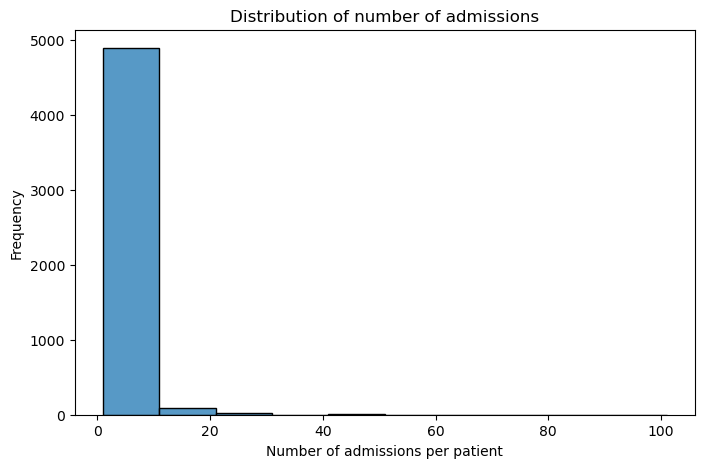

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dummy_data/cleaned_data.csv")

# Example: df has columns ['patient_id', 'admission_id']
admissions_per_patient = df.groupby("subject_id")["hadm_id"].count()

plt.figure(figsize=(8,5))
sns.histplot(admissions_per_patient, bins=10, kde=False)
plt.xlabel("Number of admissions per patient")
plt.ylabel("Frequency")
plt.title("Distribution of number of admissions")
plt.show()

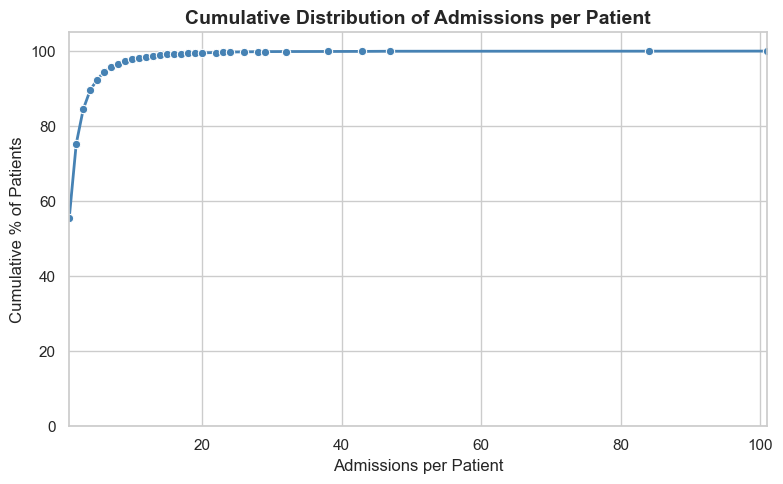

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute cumulative distribution
adm_per_patient = df.groupby("subject_id")["hadm_id"].nunique()
cum = (
    adm_per_patient.value_counts()
    .sort_index()
    .cumsum() / len(adm_per_patient) * 100
).reset_index()
cum.columns = ["Admissions_per_Patient", "Cumulative_Percent"]

# Seaborn style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))
sns.lineplot(
    data=cum,
    x="Admissions_per_Patient",
    y="Cumulative_Percent",
    marker="o",
    linewidth=2,
    color="steelblue"
)

# Labels & formatting
plt.xlabel("Admissions per Patient", fontsize=12)
plt.ylabel("Cumulative % of Patients", fontsize=12)
plt.title("Cumulative Distribution of Admissions per Patient", fontsize=14, weight="bold")
plt.ylim(0, 105)
plt.xlim(1, cum["Admissions_per_Patient"].max())
plt.tight_layout()
plt.show()


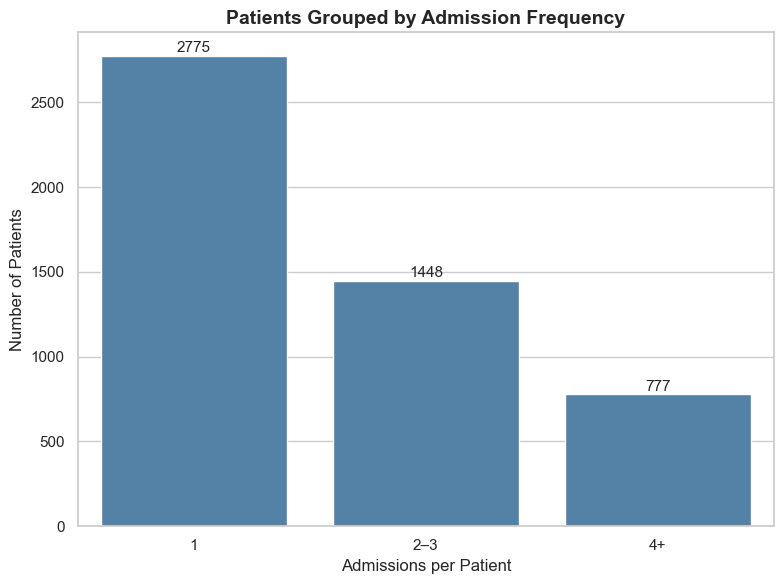

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# Number of admissions per patient
adm_per_patient = df.groupby("subject_id")["hadm_id"].nunique()

# Bin into 3 categories
bins = [0, 1, 3, adm_per_patient.max()]  # 1, 2–3, 4+
labels = ["1", "2–3", "4+"]

adm_bins = pd.cut(adm_per_patient, bins=bins, labels=labels, right=True)
adm_group_counts = adm_bins.value_counts().reindex(labels).reset_index()
adm_group_counts.columns = ["Admissions_per_Patient", "Count"]

# Seaborn style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=adm_group_counts,
    x="Admissions_per_Patient",
    y="Count",
    color="steelblue"
)

# Add annotations on top of bars
for i, row in adm_group_counts.iterrows():
    ax.text(i, row["Count"]+5, str(row["Count"]), ha="center", va="bottom", fontsize=11)

# Labels and title
plt.xlabel("Admissions per Patient", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
plt.title("Patients Grouped by Admission Frequency", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()


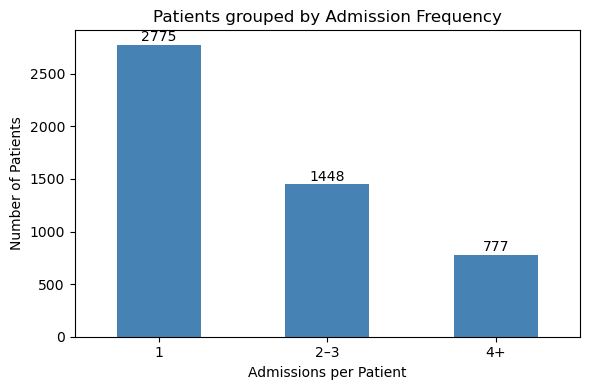

In [69]:
# Number of admissions per patient
admissions_per_patient = df.groupby("subject_id")["hadm_id"].nunique()

# Bin into 3 categories
bins = [0, 1, 3, admissions_per_patient.max()]  # 1, 2–3, 4+
labels = ["1", "2–3", "4+"]

adm_bins = pd.cut(admissions_per_patient, bins=bins, labels=labels, right=True)

# Count patients in each bin
adm_group_counts = adm_bins.value_counts().reindex(labels)

# Plot
plt.figure(figsize=(6,4))
adm_group_counts.plot(kind="bar", color="steelblue")
plt.xlabel("Admissions per Patient")
plt.ylabel("Number of Patients")
plt.title("Patients grouped by Admission Frequency")
plt.xticks(rotation=0)
for i, v in enumerate(adm_group_counts):
    plt.text(i, v+5, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

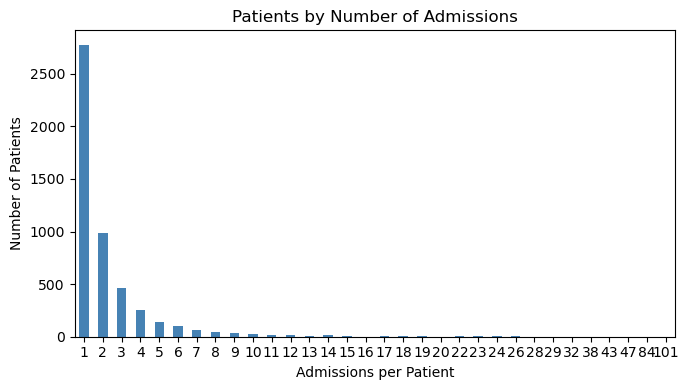

In [63]:
adm_counts = admissions_per_patient.value_counts().sort_index()

plt.figure(figsize=(7,4))
adm_counts.plot(kind="bar", color="steelblue")
plt.xlabel("Admissions per Patient")
plt.ylabel("Number of Patients")
plt.title("Patients by Number of Admissions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [3]:
admissions_per_patient.describe()

count    5000.000000
mean        2.365600
std         3.423957
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       101.000000
Name: hadm_id, dtype: float64

In [57]:
df["admission_duration"].describe()

count    11828.000000
mean         4.889202
std          7.554199
min          0.006250
25%          1.110069
50%          2.821528
75%          5.687500
max        207.152778
Name: admission_duration, dtype: float64

In [2]:
import numpy as np
lengths = np.array(admissions_per_patient)  # one length per patient
T = min(100, int(np.percentile(lengths, 99)))

In [3]:
print(T)

14


In [4]:
df.columns

Index(['subject_id', 'hadm_id', 'admission_type', 'admission_location',
       'insurance', 'language', 'marital_status', 'race',
       'hospital_expire_flag', 'ccs_seq', 'ccs_seq_len', 'gender',
       'anchor_year_group', 'admission_duration', 'ed_duration',
       'age_at_admission', 'is_weekend', 'is_night_admit', 'hour_sin',
       'hour_cos', 'dow_sin', 'dow_cos', 'mon_sin', 'mon_cos',
       'admission_index', 'days_since_prev_admission',
       'days_since_first_admission', 'num_prior_admissions',
       'has_prior_admission'],
      dtype='object')

C:\Users\amydu\AppData\Local\Temp\ipykernel_460\3290153091.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='death_label', data=df, palette='Set2')


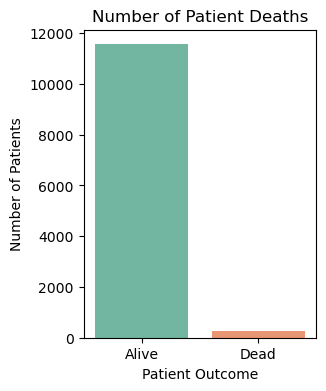

In [13]:
# Example: df has columns ['patient_id', 'admission_id']
death_per_patient = df["hospital_expire_flag"].value_counts()

# Map binary values to labels for readability
df['death_label'] = df['hospital_expire_flag'].map({0: 'Alive', 1: 'Dead'})

plt.figure(figsize=(3,4))
# Seaborn countplot (automatically counts categories)
sns.countplot(x='death_label', data=df, palette='Set2')

plt.xlabel("Patient Outcome")
plt.ylabel("Number of Patients")
plt.title("Number of Patient Deaths")
plt.show()

C:\Users\amydu\AppData\Local\Temp\ipykernel_460\1781215456.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stay_counts.index, y=stay_counts.values, palette="Set2")


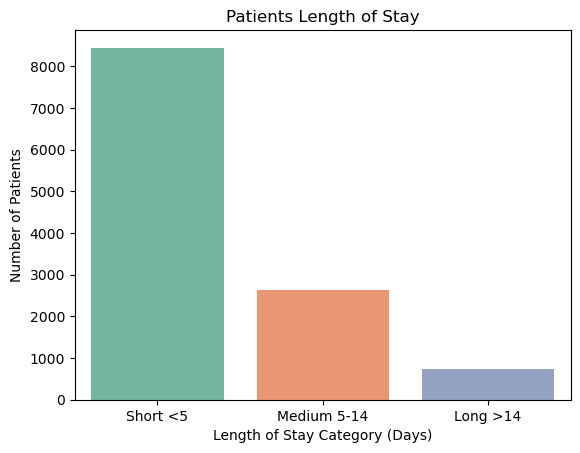

In [20]:
# Define bins: short <5, medium 5–14, long >14
bins = [0, 5, 14, float('inf')]
labels = ['Short <5', 'Medium 5-14', 'Long >14']

df['stay_category'] = pd.cut(df['admission_duration'], bins=bins, labels=labels, right=True)

# Count patients per category
stay_counts = df['stay_category'].value_counts().reindex(labels)

# Plot
sns.barplot(x=stay_counts.index, y=stay_counts.values, palette="Set2")

plt.xlabel("Length of Stay Category (Days)")
plt.ylabel("Number of Patients")
plt.title("Patients Length of Stay")
plt.show()

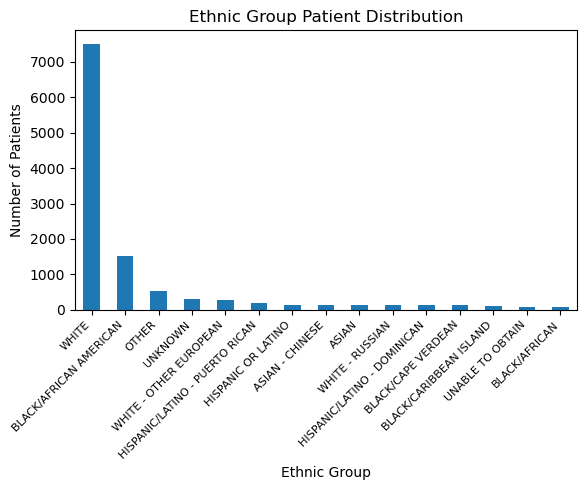

In [43]:
# Race counts
plt.figure(figsize=(6,5))
df["race"].value_counts(dropna=False).head(15).plot(kind="bar")
plt.ylabel("Number of Patients")
plt.title("Ethnic Group Patient Distribution")
plt.xlabel("Ethnic Group") 
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


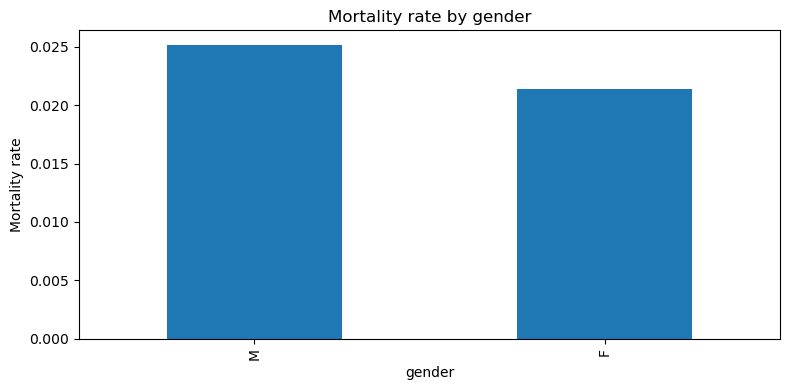

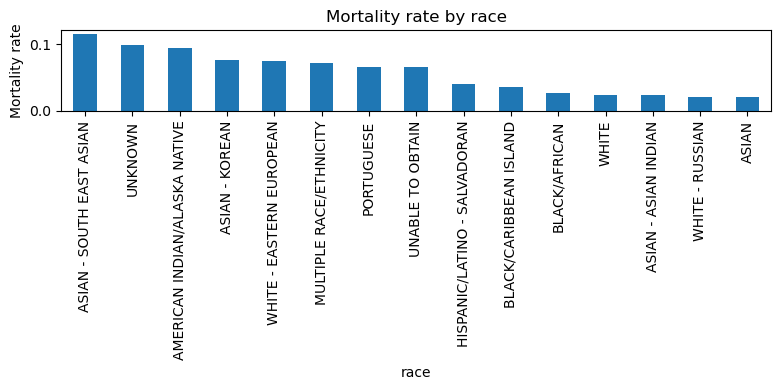

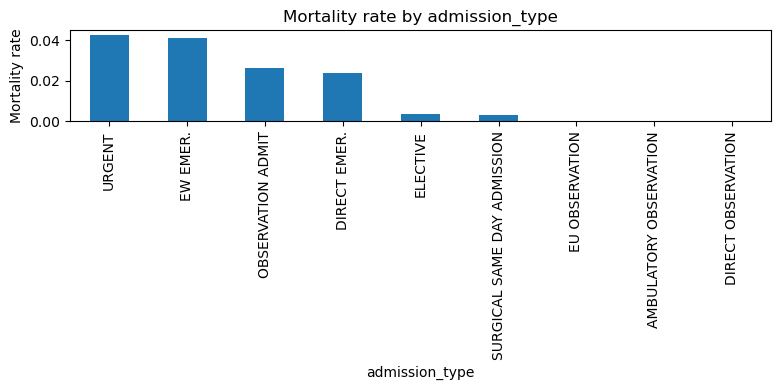

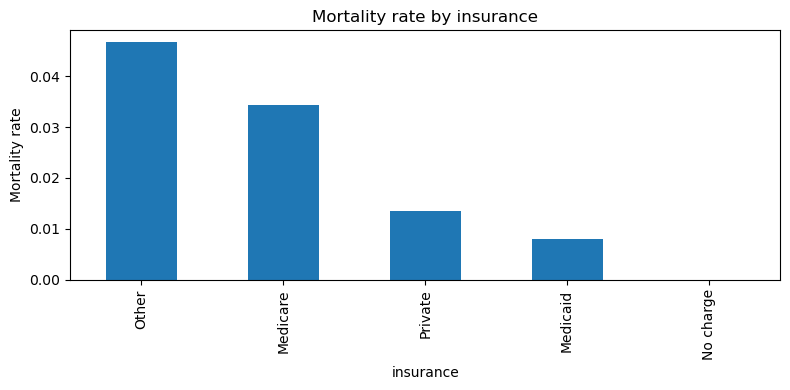

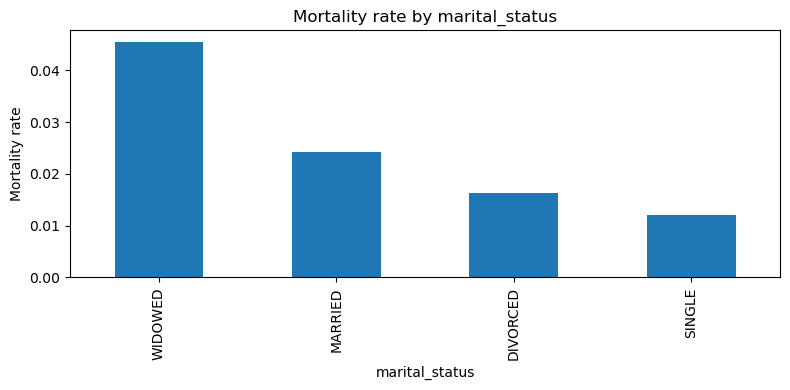

<Figure size 700x400 with 0 Axes>

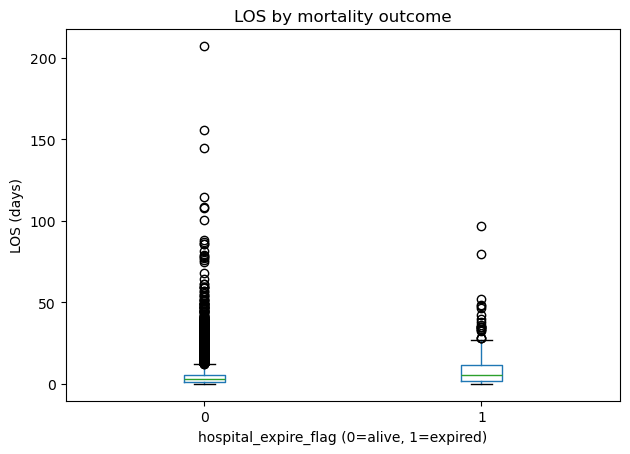

In [24]:
# Mortality by subgroup
def bar_rate(df, col, top_k=10, title=None):
    tab = df.groupby(col)["hospital_expire_flag"].mean().sort_values(ascending=False).head(top_k)
    plt.figure(figsize=(8,4))
    tab.plot(kind="bar")
    plt.ylabel("Mortality rate")
    plt.title(title or f"Mortality rate by {col}")
    plt.tight_layout()
    plt.show()

for c in ["gender","race","admission_type","insurance","marital_status","discharge_location"]:
    if c in df.columns:
        bar_rate(df, c, top_k=15, title=f"Mortality rate by {c}")

# LOS vs mortality
plt.figure(figsize=(7,4))
df.boxplot(column="admission_duration", by="hospital_expire_flag", grid=False)
plt.suptitle("")
plt.title("LOS by mortality outcome")
plt.xlabel("hospital_expire_flag (0=alive, 1=expired)")
plt.ylabel("LOS (days)")
plt.tight_layout()
plt.show()

C:\Users\amydu\AppData\Local\Temp\ipykernel_460\1797056125.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


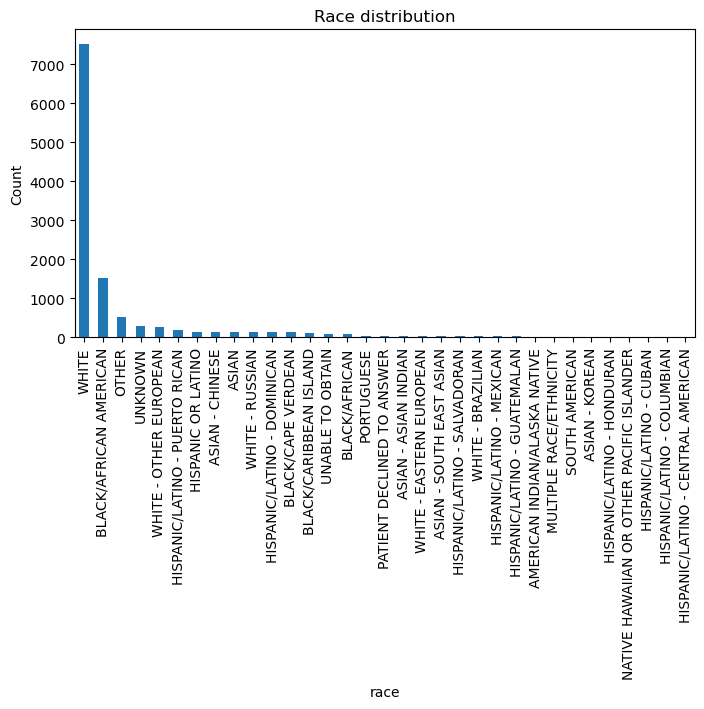

<Figure size 1000x800 with 0 Axes>

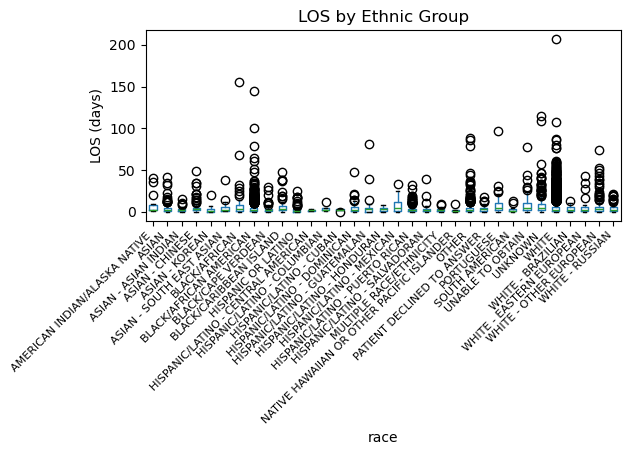

C:\Users\amydu\AppData\Local\Temp\ipykernel_460\1797056125.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


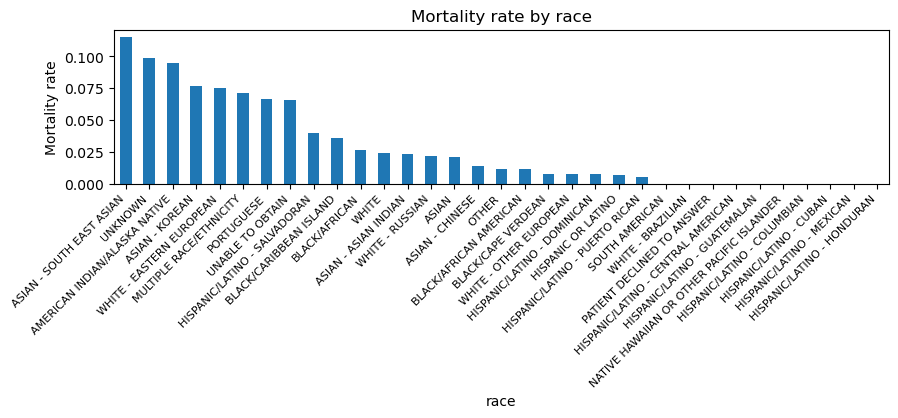

In [34]:
# Distribution of race (counts)
plt.figure(figsize=(8,4))
df["race"].value_counts().plot(kind="bar")
plt.title("Race distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# LOS by race
plt.figure(figsize=(10,8))
df.boxplot(column="admission_duration", by="race", grid=False, rot=45)
plt.suptitle("")
plt.title("LOS by Ethnic Group")
plt.ylabel("LOS (days)")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# Mortality rate by race
race_mort = df.groupby("race")["hospital_expire_flag"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,2))
race_mort.plot(kind="bar")
plt.ylabel("Mortality rate")
plt.title("Mortality rate by race")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


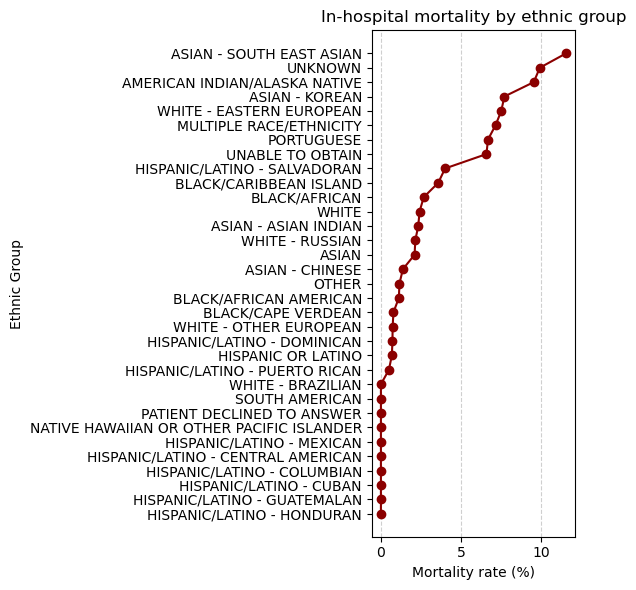

In [40]:
race_mort = df.groupby("race")["hospital_expire_flag"].mean().sort_values()
plt.figure(figsize=(6,6))
plt.plot(race_mort*100, race_mort.index, "o-", color="darkred")
plt.xlabel("Mortality rate (%)")
plt.ylabel("Ethnic Group")
plt.title("In-hospital mortality by ethnic group")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

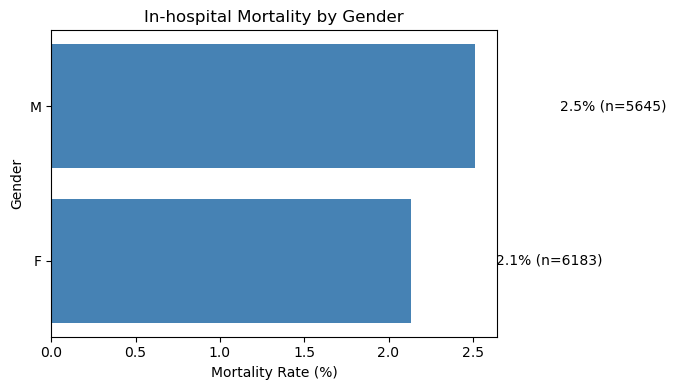

In [50]:
gender_mort = df.groupby("gender").agg(
    mort=("hospital_expire_flag","mean"),
    n=("gender","size")
).sort_values("mort")

plt.figure(figsize=(7,4))
x = gender_mort["mort"]*100
y = gender_mort.index
plt.barh(y, x, color="steelblue")
for i, (val, cnt) in enumerate(zip(x, gender_mort["n"])):
    plt.text(val+0.5, i, f"{val:.1f}% (n={cnt})", va="center")
plt.xlabel("Mortality Rate (%)")
plt.ylabel("Gender")
plt.title("In-hospital Mortality by Gender")
plt.tight_layout()
plt.show()

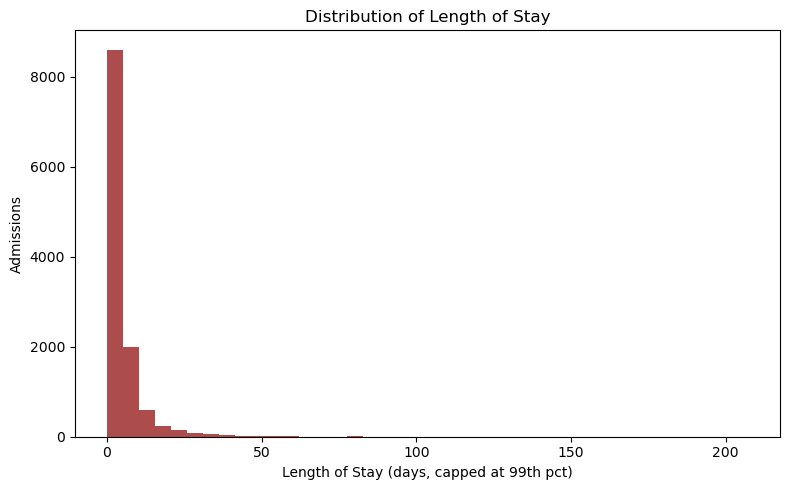

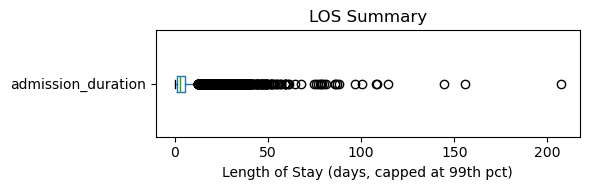

In [ ]:
# Histogram
plt.figure(figsize=(8,5))
df["admission_duration"].dropna().plot(kind="hist", bins=40, color="darkred", alpha=0.7)
plt.xlabel("Length of Stay (days, capped at 99th pct)")
plt.ylabel("Admissions")
plt.title("Distribution of Length of Stay")
plt.tight_layout()
plt.show()

# Boxplot for comparison
plt.figure(figsize=(6,2))
df[["admission_duration", "ed_duration", ]].boxplot(vert=False, grid=False)
plt.xlabel("Length of Stay (days, capped at 99th pct)")
plt.title("LOS Summary")
plt.tight_layout()
plt.show()

<Figure size 1000x700 with 0 Axes>

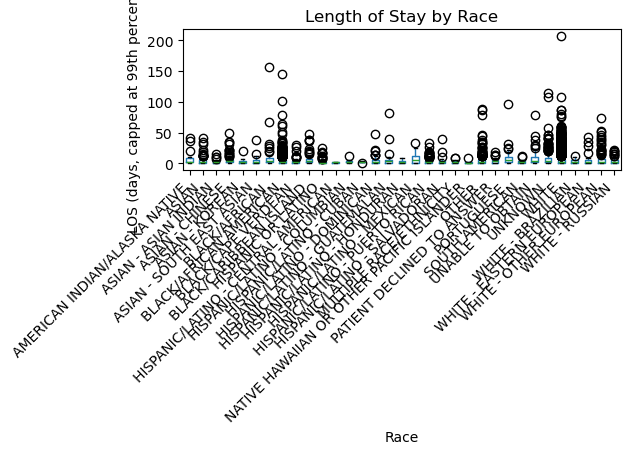

In [55]:
plt.figure(figsize=(10,7))
df.boxplot(column="admission_duration", by="race", grid=False)
plt.suptitle("")  # remove default pandas title
plt.title("Length of Stay by Race")
plt.xlabel("Race")
plt.ylabel("LOS (days, capped at 99th percentile)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()